# Tutorial 3: Integration of spatial epigenome-transcriptome mouse brain coronal dataset.

This notebook provides a step-by-step guide on how to obtain joint embeddings on the mouse brain coronal dataset.

In [ ]:
# Import required libraries and dependencies
import torch
import warnings
import scanpy as sc
import matplotlib.pyplot as plt

from maple.model import *
from maple.utils import *
from maple.metrics import *
from maple.preprocess import *
from sklearn.preprocessing import StandardScaler

# Initialize global settings
seed = 114511
fix_seed(seed)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
warnings.filterwarnings('ignore', category=UserWarning)

Global random seed set to: 114511.


In [2]:
# Load the mouse brain coronal dataset
adata_rna = sc.read_h5ad('../data/mouse_brain_coronal/adata_rna.h5ad')
adata_atac = sc.read_h5ad('../data/mouse_brain_coronal/adata_atac.h5ad')

# Preprocess the RNA data
adata_rna.layers['counts'] = adata_rna.X.copy()
sc.pp.highly_variable_genes(adata_rna, flavor='seurat_v3', n_top_genes=3000)
sc.pp.normalize_total(adata_rna, target_sum=1e4)
sc.pp.log1p(adata_rna)
sc.pp.scale(adata_rna)
adata_rna.obsm['X_feat'] = compute_pca(adata_rna[:, adata_rna.var['highly_variable']].X, 30)

# Preprocess the ATAC data
adata_atac.layers['counts'] = adata_atac.X.copy()
extract_hvps_by_coarse_clustering(adata_atac)
sc.pp.scale(adata_atac)
scaler = StandardScaler()
adata_atac.obsm['X_feat'] = scaler.fit_transform(adata_atac.obsm['X_feat'])

# Inspect the processed data
adata_rna, adata_atac

(AnnData object with n_obs × n_vars = 9215 × 22914
     obs: 'rna_clusters'
     var: 'feature_types', 'genome', 'gene_symbol', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
     uns: 'hvg', 'log1p'
     obsm: 'spatial', 'X_feat'
     layers: 'counts',
 AnnData object with n_obs × n_vars = 9215 × 121068
     obs: 'atac_clusters', 'coarse_leiden'
     var: 'count', 'percentile', 'feature_types', 'genome', 'highly_variable', 'mean', 'std'
     uns: 'coarse_knn', 'coarse_leiden', 'coarse_rank_peaks'
     obsm: 'X_feat', 'spatial'
     layers: 'counts'
     obsp: 'coarse_knn_distances', 'coarse_knn_connectivities')

In [3]:
# Create a MAPLE model and initialize it
maple = MAPLE(
        adata_rna=adata_rna,
        adata_atac=adata_atac,
        latent_dim=20,
        n_spat_neighbors=24,
        device=device
    )

# Train the MAPLE model
maple.train_modal()

The spatial, feature, and joint graphs have been successfully generated.
Loaded pre-computed real gene ontology graph from '../data/feature_prior/go_graphs/go_graph_20260522_153245.npz'.
The spatial, feature, and joint graphs have been successfully generated.
Loaded pre-computed real transcription factor graph from '../data/feature_prior/tf_graphs/tf_graph_20260522_153310.npz'.
The real cross-modal regulatory graph has been successfully generated.


Training:  54%|█████▍    | 1078/2000 [00:18<00:15, 59.44it/s, recon_loss_rna=0.992758, recon_loss_atac=0.828757, recon_loss_atac_hvp=0.985804, reg_loss=0.996297, total_loss=3.803617]


Early stopping triggered at epoch 1079.
Total training time: 18.14 seconds.
Peak GPU memory usage: 1390.62 MB.


In [4]:
# Prepare a new AnnData for unified qualitative and quantitative analysis
adata = adata_rna.copy()
adata.obsm['rna_X_feat'] = adata.obsm.pop('X_feat')
adata.obsm['atac_X_feat'] = adata_atac.obsm['X_feat'].copy()

# Extract the joint embeddings
with torch.no_grad():
    maple.eval()
    results = maple.forward()
    adata.obsm['maple_emb'] = results['joint_emb'].cpu().numpy()

# Perform Leiden clustering on the joint embeddings
optimize_leiden(adata=adata, n_clusters=16, used_obsm='maple_emb',
                add_obs='maple_leiden', res_min=0.5, res_max=1.5)

Current resolution is 1.0000, found 15 clusters.
Current resolution is 1.2500, found 19 clusters.
Current resolution is 1.1250, found 18 clusters.
Current resolution is 1.0625, found 18 clusters.
Current resolution is 1.0312, found 17 clusters.
Current resolution is 1.0156, found 16 clusters.
Success: Leiden found 16 clusters at resolution 1.0156 (Attempt 6).


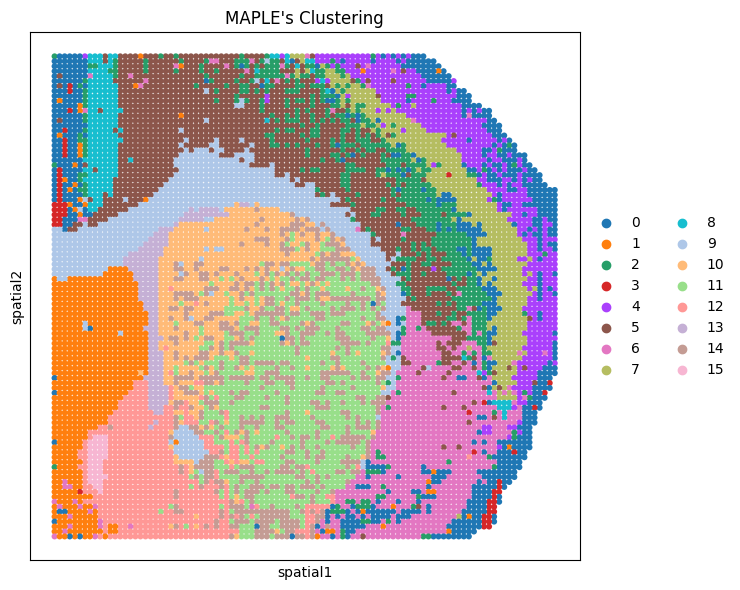

In [5]:
# Visualize MAPLE's clustering
fig, ax = plt.subplots(figsize=(7.5, 6))

sc.pl.embedding(adata, basis='spatial', title='MAPLE\'s Clustering', color='maple_leiden', ax=ax, s=75, show=False)

plt.tight_layout()
plt.show()

In [ ]:
# Calculate unsupervised metrics for spatial domain segmentation
rna_ficc, rna_cicc_df, rna_gicc = calculate_icc(adata, 'rna_X_feat', 'maple_leiden')
atac_ficc, atac_cicc_df, atac_gicc = calculate_icc(adata, 'atac_X_feat', 'maple_leiden')
rna_js = calculate_js(adata, 'rna_X_feat', 'maple_emb', 30)
atac_js = calculate_js(adata, 'atac_X_feat', 'maple_emb', 30)

print(f'rna-ficc: {rna_ficc:.4f}, atac-ficc: {atac_ficc:.4f}, rna-gicc: {rna_gicc:.4f}, atac-gicc: {atac_gicc:.4f}, rna-js: {rna_js:.4f}, atac-js: {atac_js:.4f}.')

rna-ficc: 0.1026, atac-ficc: 0.1238, rna-gicc: 0.3145, atac-gicc: 0.3738, rna-js: 0.0244, atac-js: 0.0475.
